# 01 — Raw Data Exploration

### 1. Objective
Why are we inspecting the corpus before training?

### 2. Load the raw dataset

### 3. Basic dataset statistics
- number of stories
- total characters
- average length
- min/max length

### 4. Inspect examples
- first few stories
- different length examples

### 5. Length distribution
- histogram
- percentiles

### 6. Duplicate analysis
- exact duplicates
- duplicate percentage

### 7. Text quality checks
- empty stories
- unusual characters
- very short stories
- very long stories

### 8. Train vs validation comparison

### 9. What did we learn?

### 10. Decisions for the tokenizer/data pipeline


In [16]:
import json
from statistics import mean

for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    lengths = [len(x) for x in texts]

    print(f'{name}:')
    print('  stories:', len(texts))
    print('  characters:', sum(lengths))
    print('  avg chars:', round(mean(lengths), 2))
    print('  min chars:', min(lengths))
    print('  max chars:', max(lengths))

train:
  stories: 25000
  characters: 20087753
  avg chars: 803.51
  min chars: 249
  max chars: 4149
val:
  stories: 2000
  characters: 1617811
  avg chars: 808.91
  min chars: 330
  max chars: 3146


#### 1. Length distribution

Look at median, P90/P95/P99 and a histogram.

This tells us whether the average of ~800 characters represents most stories or hides a long tail.

In [27]:
from statistics import quantiles
import matplotlib.pyplot as plt

all_lengths = {}

for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    lengths = [len(x) for x in texts]
    all_lengths[name] = lengths

    pct = quantiles(lengths, n=100, method='inclusive')

    print(f'{name}:')
    print(' Median:', pct[49])
    print(' P90:', pct[89])
    print(' P95:', pct[94])
    print(' P99:', pct[98])


train:
 Median: 720.0
 P90: 1090.1
 P95: 1470.0
 P99: 2267.0
val:
 Median: 725.0
 P90: 1088.0
 P95: 1504.3
 P99: 2273.68


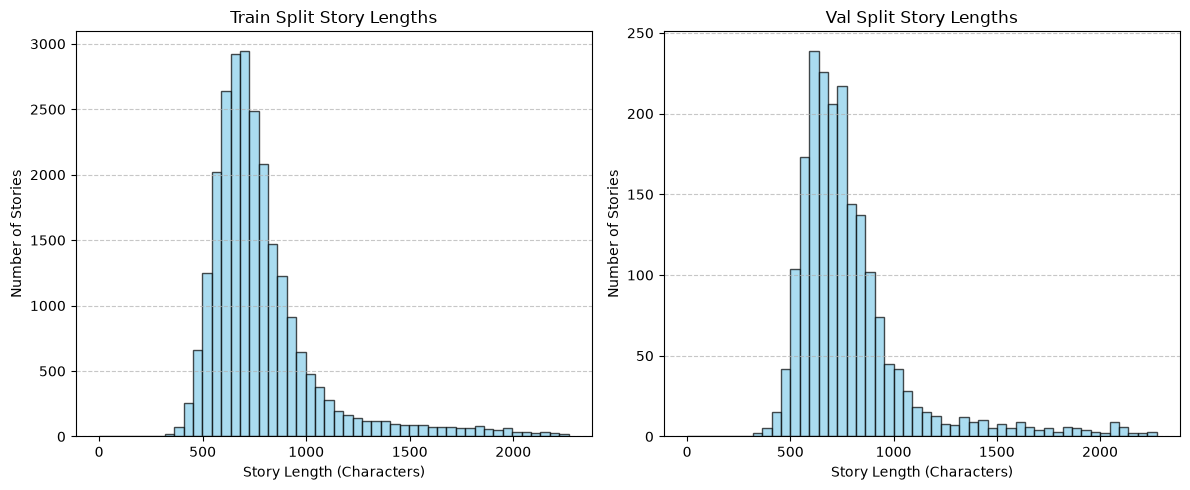

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for i, name in enumerate(['train', 'val']):
    # plt.hist automatically groups lengths into 'bins' (bars)
    # range=(0, p99) chops off the top 1% extreme outliers so the chart looks clean
    p99_value = quantiles(all_lengths[name], n=100, method='inclusive')[98]
    
    axes[i].hist(all_lengths[name], bins=50, range=(0, p99_value), color='skyblue', edgecolor='black', alpha=0.7)
    
    # Customizing the chart appearance
    axes[i].set_title(f'{name.capitalize()} Split Story Lengths')
    axes[i].set_xlabel('Story Length (Characters)')
    axes[i].set_ylabel('Number of Stories')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### 2. Word statistics

Understand approximate words/story and overall word volume. This gives an intuitive baseline before switching to subword tokens.

In [40]:
for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    word_counts = [len(x.split()) for x in texts]

    print(f'{name}:')
    print('  stories:', len(texts))
    print('  total words:', sum(word_counts))
    print('  avg words per story:', round(mean(word_counts), 2))
    print('  min words per story:', min(word_counts))
    print('  max words per story:', max(word_counts))


train:
  stories: 25000
  total words: 4015358
  avg words per story: 160.61
  min words per story: 50
  max words per story: 827
val:
  stories: 2000
  total words: 323890
  avg words per story: 161.94
  min words per story: 67
  max words per story: 641


#### 3. Character vocabulary

Count unique characters and inspect punctuation, quotes, apostrophes, digits, whitespace, and any non-ASCII characters. This leads naturally into understanding why we're choosing byte-level BPE.

unique characters ->
most frequent characters ->
ASCII vs non-ASCII ->
punctuation ->
quotes -> 
apostrophes ->
digits ->
whitespace/newlines

In [41]:
for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    all_text = ' '.join(texts)
    unique_chars = set(all_text)

    print(f'{name}:')
    print('  unique characters:', len(unique_chars))
    print('  characters:', sorted(unique_chars))


train:
  unique characters: 74
  characters: ['\n', ' ', '!', '"', '$', "'", ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
val:
  unique characters: 64
  characters: ['\n', ' ', '!', '"', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


#### 4. Data quality

Check empty/whitespace records, unusually short/long samples, malformed text, and strange formatting.

empty stories ->
duplicate stories ->
train ↔ validation overlap ->
unusual/control characters

In [42]:
for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    print(f'{name}:')
    print('  empty stories:', len([x for x in texts if len(x.strip()) == 0]))
    print('  short stories (< 10 chars):', len([x for x in texts if len(x) < 10]))
    print('  long stories (> 2000 chars):', len([x for x in texts if len(x) > 2000]))

    # Check for duplicates
    unique_texts = set(texts)
    print('  duplicate stories:', len(texts) - len(unique_texts))

    # Check for unusual characters
    all_text = ' '.join(texts)
    ascii_chars = sum(1 for c in all_text if ord(c) < 128)
    print('  ASCII characters:', ascii_chars)
    print('  non-ASCII characters:', len(all_text) - ascii_chars)

train:
  empty stories: 0
  short stories (< 10 chars): 0
  long stories (> 2000 chars): 422
  duplicate stories: 0
  ASCII characters: 20112752
  non-ASCII characters: 0
val:
  empty stories: 0
  short stories (< 10 chars): 0
  long stories (> 2000 chars): 44
  duplicate stories: 0
  ASCII characters: 1619810
  non-ASCII characters: 0


#### 6. Sample inspection

Look at a few random stories plus very short/medium/long examples. We want to understand the actual text structure, not just statistics.

short stories ->
median-sized stories ->
long stories ->
random stories

In [43]:
for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    print(f'\n{name.upper()} SAMPLES:')
    print('=' * 50)

    # Print first 3 stories
    for i, text in enumerate(texts[:3]):
        print(f'Story {i+1} (len={len(text)}):')
        print(repr(text))
        print()

    # Print a few medium-length stories
    med_length = int(len(texts) / 2)
    for i, text in enumerate(texts[med_length:med_length+2]):
        print(f'Med Story {i+1} (len={len(text)}):')
        print(repr(text))
        print()

    # Print a few long stories
    sorted_texts = sorted(texts, key=len, reverse=True)
    for i, text in enumerate(sorted_texts[:2]):
        print(f'Long Story {i+1} (len={len(text)}):')
        print(repr(text))
        print()



TRAIN SAMPLES:
Story 1 (len=715):
'Once upon a time, in a small house, there lived a clumsy dog named Spot. Spot liked to play and run all day. In the evening, when the sun went down, Spot would get very tired.\nOne evening, after a long day of playing, Spot was very thirsty. He wanted to drink some water. So, he went to his bowl to drink. But, because he was so clumsy, he knocked the bowl over and water went everywhere!\nSpot felt bad about being clumsy, but his owner, a little girl named Sarah, just laughed. She said, "Silly Spot, you\'re always so clumsy!" She cleaned up the water and filled the bowl again. This time, Spot was very careful and drank his water without making a mess. They both went to bed happy and ready for a new day of fun.'

Story 2 (len=725):
"Once upon a time, there was a slow turtle named Tim. Tim liked to drive his little red car around town. One day, he could not find his license. He looked everywhere for it. Tim was sad because he could not drive without his

In [ ]:
# Does any exact story appear in both train and validation?

for name in ['train', 'val']:
    texts = []
    with open(f'../data/raw/{name}.jsonl', encoding='utf-8') as f:
        for line in f:
            texts.append(json.loads(line)['text'])

    train_texts = set()
    if name == 'train':
        for text in texts:
            train_texts.add(text)

for text in texts:
    if text in train_texts:
        print('Duplicate found!')
        print(repr(text))
        break
else:
        print('No duplicate found!')

# # much cleaner code
# with open('../data/raw/train.jsonl', encoding='utf-8') as f:
#     train_texts = {json.loads(line)['text'] for line in f}

# with open('../data/raw/val.jsonl', encoding='utf-8') as f:
#     val_texts = {json.loads(line)['text'] for line in f}

# overlap = train_texts.intersection(val_texts)
# print(f'Train ↔ Validation exact duplicates: {len(overlap)}')

# if overlap:
#     print('Duplicate found!')
#     print(repr(next(iter(overlap))))
# else:
#     print('No duplicate found!')


No duplicate found!


### Key findings

- 25,000 training stories and 2,000 validation stories
- ~20.09M training characters and ~1.62M validation characters
- Train and validation have very similar length distributions
- 74 unique characters in train, 64 in validation
- All observed characters are ASCII
- No empty or extremely short stories
- No duplicate stories within either split
- No exact overlap between train and validation
- The corpus has normal narrative text, punctuation, dialogue, and paragraph boundaries

### Decision

The corpus is suitable for the initial Mini GPT experiment.

Next phase:
We will build a byte-level BPE tokenizer from scratch and measure how the
20M-character corpus translates into actual model tokens.